# Dataset Preparation

- input: curated briefsummary
- output: pd.series of ase objects pr pymatgen objects


In [1]:
from Tools.DatasetTools.Commoms import *
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer
from Tools.DatasetTools.Tools import need_to_update
from Tools.DatasetTools.SublatticeSorter import *
from pymatgen.io.ase import AseAtomsAdaptor
from mendeleev import element

In [2]:
from mp_api.client import MPRester

# options 

In [3]:
dataset = 'Fe-Mo'  # 'Cr-Co-W' 'Fe-Mo'
case = 'POSCAR-initial'  # 'POSCAR-relaxed']
rescale_by_atoms = True #  False]
subcase = 'rescaled' #  'noscaled' ] 
Force = True
CuratedBS = os.path.join(dataset,'FurtherCuratedParsedBriefSummary.pkl')

In [4]:
MP_keys = {'Fe' : 'mp-13', 'Mo' : 'mp-129'}

In [5]:
BS = pd.read_pickle(CuratedBS)

In [6]:
bcc_bs = BS.loc[BS.index.str.contains('Fe.*bcc.*FM', regex=True)]

In [7]:
bcc_bs

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc,Phase
Fe_pv2.bcc-cubic.FM,bulk bcc-cubic.FM,11.367016 A,-8.254731,187.308419 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.015,0,1,...,,2,0,2,1.0,0.0,0.000000,0.000000,0.000000,bcc
Fe_pv1.bcc.FM,bulk bcc.FM,11.352006 A,-8.255228,170.727430 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.016,0,1,...,,1,0,1,1.0,0.0,0.000825,0.000825,0.000825,bcc


In [8]:
Features = Featurizer(BS)

chech that the chemistry resetting is correct!

In [9]:
ground_states = pd.Series(Features.get_ground_states_energies())

In [10]:
ground_states

Fe_pv1  bcc  FM    -8.255228
Fe_pv2  hcp  NM    -8.184072
Mo_sv1  bcc  FM   -10.932755
             NM   -10.932821
dtype: float64

In [11]:
ground_state_samples = ground_states.index.map(lambda t: '.'.join(t))

In [12]:
ground_state_samples

Index(['Fe_pv1.bcc.FM', 'Fe_pv2.hcp.NM', 'Mo_sv1.bcc.FM', 'Mo_sv1.bcc.NM'], dtype='object')

In [13]:
BS.loc[ground_state_samples]['V'] #index#.str.split('.', )

Fe_pv1.bcc.FM    11.352006 A 
Fe_pv2.hcp.NM    10.193118 A 
Mo_sv1.bcc.FM    15.827863 A 
Mo_sv1.bcc.NM    15.828881 A 
Name: V, dtype: object

In [14]:
atom_volume_keys = {}
with  MPRester("XMK2lneoOyVOQDnhEnVmyX3h4dyJuSyo") as mpr:
    for atom, key in MP_keys.items():
        result =mpr.summary.search(material_ids=[key])[0]
        total_vol = result.volume
        nsites = result.nsites
        atom_volume_keys[atom] = total_vol/nsites

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
atom_volume_keys

{'Fe': 11.734084234678496, 'Mo': 15.89162790660502}

In [16]:
Features = Featurizer(BS)

# Sort Poscar files

In [17]:
searchs = 'POSCAR.initial'
files = get_file_paths(dataset, searchs)
atomsobjectslocation = os.path.join(dataset,'Atomsobjects')
sublatticesortersfile = os.path.join(atomsobjectslocation, 'SORTERS.pkl')
sublatticetagfile = os.path.join(atomsobjectslocation, 'SUBLATICETAGS.pkl')

In [18]:
sublatticesortersfile

'Fe-Mo/Atomsobjects/SORTERS.pkl'

In [19]:
if True: # not os.path.exists(sublatticesortersfile): # need_to_update(sublatticesortersfile) or need_to_update(sublatticetagfile):
    SORTERS, SUBLATICETAGS = get_all_sorters_and_tags(dataset, files)
    SORTERS.to_pickle(sublatticesortersfile)
    SUBLATICETAGS.to_pickle(sublatticetagfile)
else:
    SORTERS = pd.read_pickle(sublatticesortersfile)
    SUBLATICETAGS = pd.read_pickle(sublatticetagfile)

  0%|          | 0/766 [00:00<?, ?it/s]

# Now I have to pick the atoms objects

In [20]:
#for thiscase, (thisrescale, thissubcase) in product(case, zip(rescale_by_atoms, subcase)):
#database = f'{dataset}/**/{case}'
AtomsFile = os.path.join(atomsobjectslocation,f'{dataset}-{case}-{subcase}-AtomsObjects.pkl')

In [21]:
if False : #not need_to_update(AtomsFile):  #os.path.exists(AtomsFile) and not Force:
    Atoms_Objects = pd.read_pickle(AtomsFile)
else:
    Atoms_Objects, CantMake_Atoms_Object = Features.get_atoms_object(
        database=dataset,
        rescale_by_atoms=True,
        reset_chemistry=True,
        file_filter = 'initial$',
        element_volumes=atom_volume_keys
    )
    Atoms_Objects.to_pickle(AtomsFile)
    Atoms_Objects.dropna(inplace=True)
pymatgenfile = AtomsFile.replace('AtomsObjects','PymatgenStructures')
Pymatgen_Structures = Atoms_Objects.copy()
if False: # not need_to_update(pymatgenfile):
    Pymatgen_Structures = pd.read_pickle(pymatgenfile)
else:
    Pymatgen_Structures = Atoms_Objects['atoms'].apply(AseAtomsAdaptor.get_structure)
    Pymatgen_Structures['file'] = Atoms_Objects['file']
    Pymatgen_Structures.to_pickle(pymatgenfile)

  0%|          | 0/292 [00:00<?, ?it/s]

In [22]:
allindex = Atoms_Objects.index.intersection(BS.index)

In [23]:
Atoms_Objects = Atoms_Objects.loc[allindex]

In [24]:
Atoms_Objects.to_pickle(AtomsFile)

In [25]:
accomodatewrap = Atoms_Objects.atoms.map(lambda a: a.wrap(pretty_translation=True))

In [26]:
difference = BS.index.difference(Atoms_Objects.index)

In [27]:
difference

Index([], dtype='object')

#  visualization of some structures

In [28]:
plt.rc('axes.spines', bottom=False, top=False, right=False, left=False)

In [29]:
from ase.visualize.plot import plot_atoms

In [30]:
Atoms_Objects

,atoms,file
Fe_pv29.chi.FM,"(Atom('Fe', [1.7306416024413072, 1.73064160244...",[Fe-Mo/rawdata/Fe_pv/bulk/chi.FM/relax/xc=PBE-...
Fe_pv6.C15.FM,"(Atom('Fe', [3.277354993348077, 3.277354993348...",[Fe-Mo/rawdata/Fe_pv/bulk/C15.FM/relax/xc=PBE-...
Fe_pv24.C36.FM,"(Atom('Fe', [0.0, 0.0, 1.4175947981681296], in...",[Fe-Mo/rawdata/Fe_pv/bulk/C36.FM/relax/xc=PBE-...
Fe_pv2.hcp.FM,"(Atom('Fe', [0.4251115225097194, 0.73631475586...",[Fe-Mo/rawdata/Fe_pv/bulk/hcp.FM/relax/xc=PBE-...
Fe_pv4.fcc-cubic.FM,"(Atom('Fe', [0.0, 1.8035979594728138, 1.803597...",[Fe-Mo/rawdata/Fe_pv/bulk/fcc-cubic.FM/relax/x...
...,...,...
Fe_pv2Mo_sv11.mu-BBBBA.FM,"(Atom('Fe', [-1.0941841505491117, 0.6317272193...",[Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/mu-BBBBA.FM/re...
Fe_pv6Mo_sv24.sigma-AABBB.FM,"(Atom('Fe', [1.7462236384492564, 1.74622363844...",[Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/sigma-AABBB.FM...
Fe_pv4Mo_sv26.sigma-BABBB.FM,"(Atom('Fe', [5.577826065046052, 5.577826065046...",[Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/sigma-BABBB.FM...
Fe_pv16Mo_sv8.C36-ABBAA.NM,"(Atom('Fe', [0.39517290770537083, -0.684459234...",[Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAA/rela...


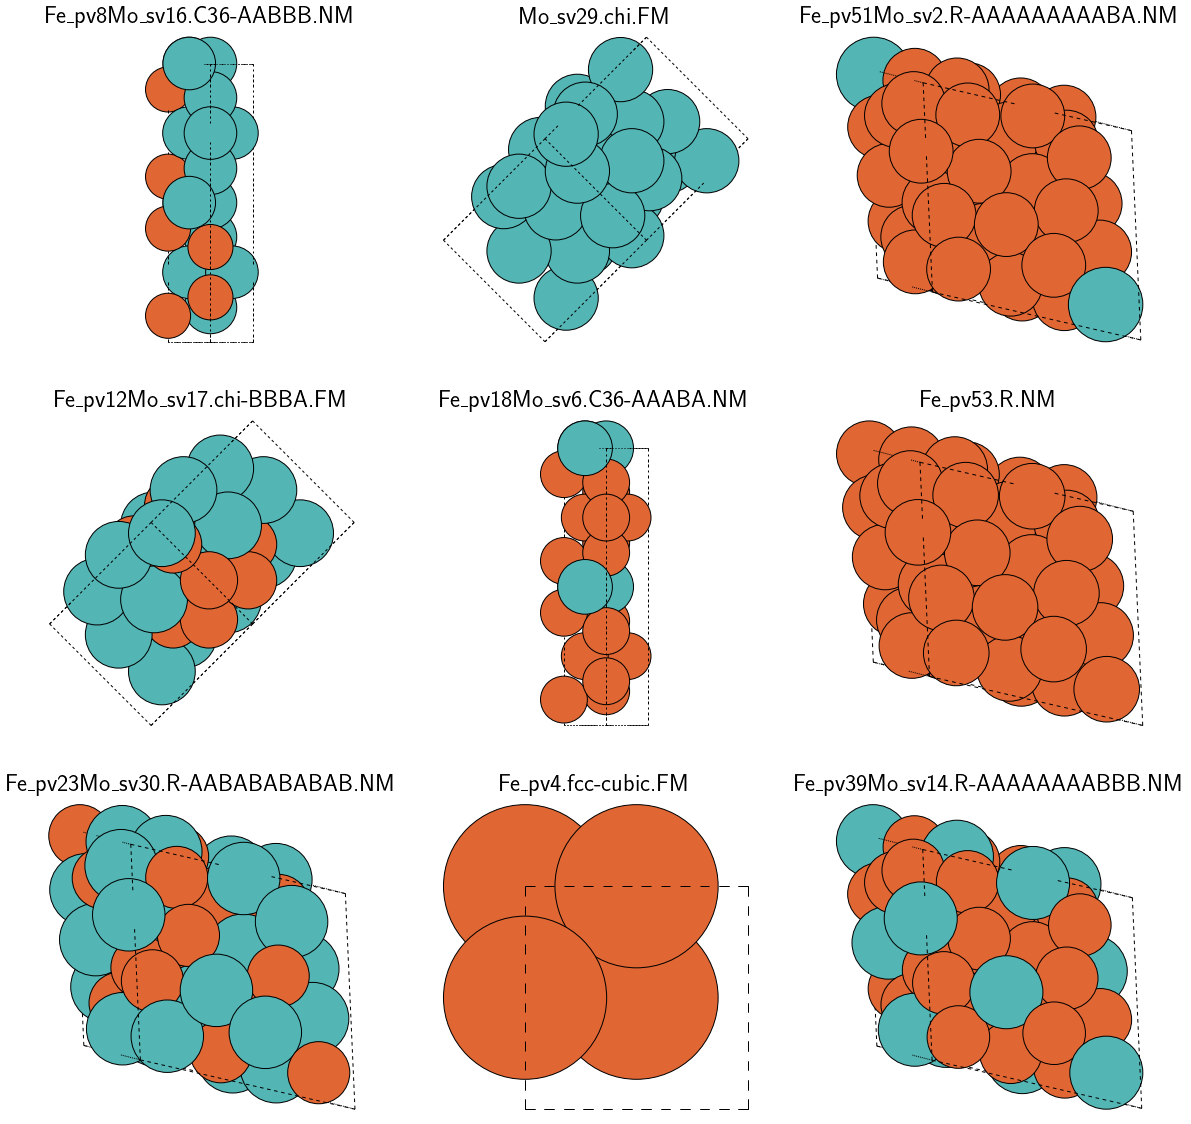

In [31]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, atoms_samples.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation = '90x')
#    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

In [32]:
somesigmas = Atoms_Objects.atoms[Atoms_Objects.index.str.contains('sigma')].sample(n=9)

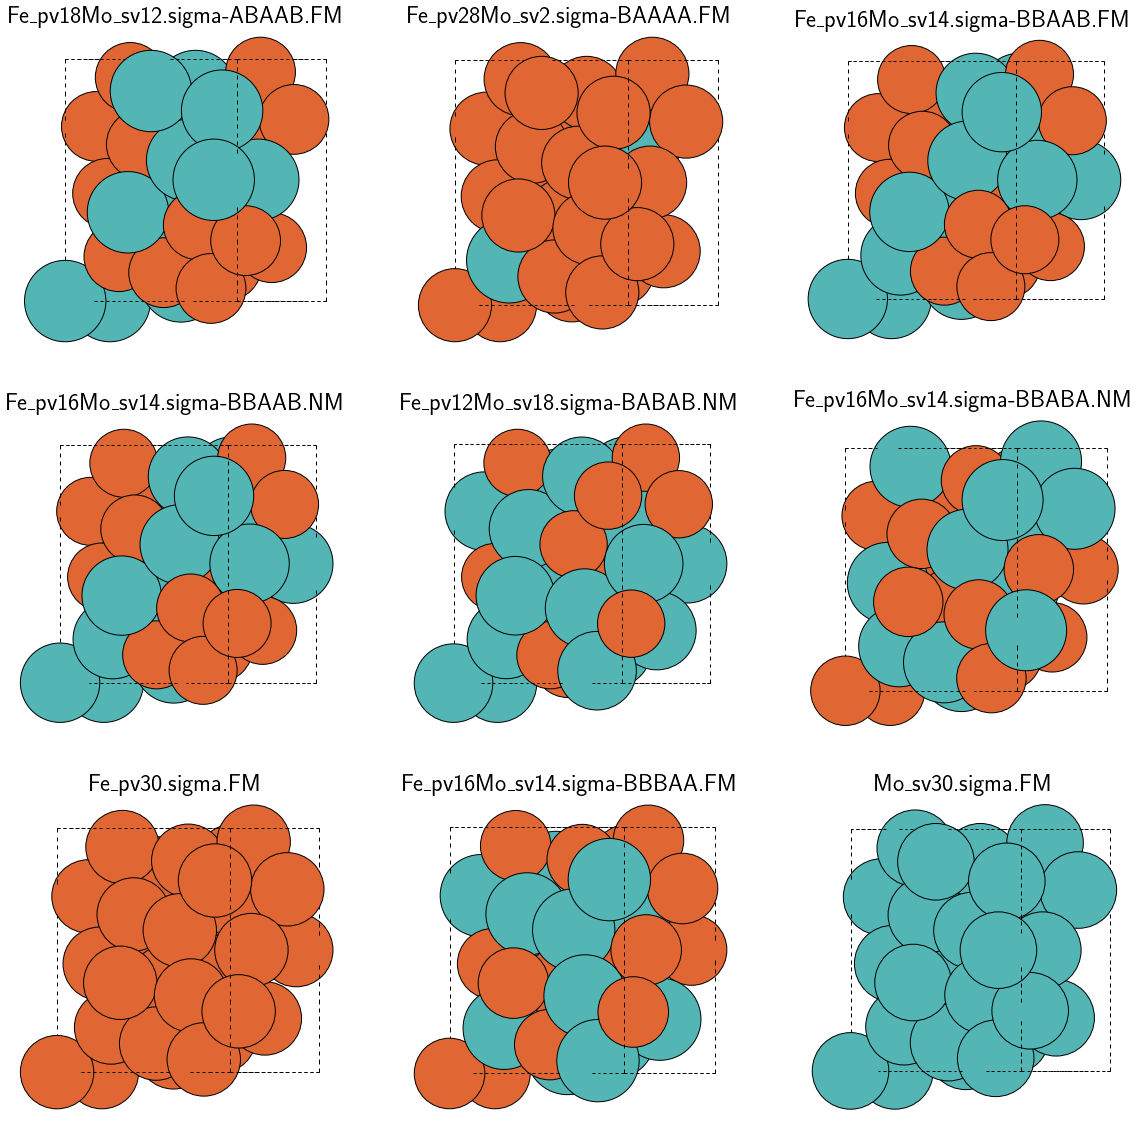

In [33]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, somesigmas.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation='90y, 90x, 45y')
    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

 For the actual visualization of the structures, we should choose one example for each structure and then draw in Vesta or Ovito for good quality figures, including coordination polyhedra etc.

# Curate Dataset to available structures 

There are still some R structures not available in data but present in briefsummaries

In [34]:
Problems = BS.index.difference(Atoms_Objects.index)

In [35]:
BS.loc[Problems]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc,Phase


In [36]:
GoodBS = BS.loc[Atoms_Objects.index]

In [37]:
GoodBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc,Phase
Fe_pv29.chi.FM,bulk chi.FM,12.050793 A,-8.137580,152.259441 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,29,0,29,1.000000,0.000000,0.117795,0.117795,0.117795,chi
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111059,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,,6,0,6,1.000000,0.000000,0.143766,0.143766,0.143766,C15
Fe_pv24.C36.FM,bulk C36.FM,12.049606 A,-8.109712,150.452690 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,24,0,24,1.000000,0.000000,0.145129,0.145129,0.145129,C36
Fe_pv2.hcp.FM,bulk hcp.FM,12.028001 A,-8.065627,165.551953 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,2,0,2,1.000000,0.000000,0.189213,0.189213,0.189213,hcp
Fe_pv4.fcc-cubic.FM,bulk fcc-cubic.FM,14.617122 A,-8.109612,-257.002805 GPa,murnaghan volume_relaxed,PBE-PAW,500,0.015,0,1,...,,4,0,4,1.000000,0.000000,0.193968,0.193968,0.193968,fcc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv2Mo_sv11.mu-BBBBA.FM,bulk mu-BBBBA.FM,15.657051 A,NaN,235.050057 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.019,0,2,...,Mo_sv,2,11,13,0.153846,0.846154,0.374468,0.374468,0.374468,mu
Fe_pv6Mo_sv24.sigma-AABBB.FM,bulk sigma-AABBB.FM,15.390750 A,NaN,224.303453 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.019,0,2,...,Mo_sv,6,24,30,0.200000,0.800000,0.235002,0.235002,0.235002,sigma
Fe_pv4Mo_sv26.sigma-BABBB.FM,bulk sigma-BABBB.FM,15.537552 A,NaN,239.757549 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.019,0,2,...,Mo_sv,4,26,30,0.133333,0.866667,0.312380,0.312380,0.312380,sigma
Fe_pv16Mo_sv8.C36-ABBAA.NM,bulk C36-ABBAA,12.475250 A,NaN,257.520617 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.018,0,2,...,Mo_sv,16,8,24,0.666667,0.333333,0.232895,0.185712,0.132999,C36


In [38]:
FullyCuratedBSFile = os.path.join(dataset,'FullyCuratedParsedBriefSummary.pkl')

In [39]:
GoodBS.to_pickle(FullyCuratedBSFile)

#  Final Distributions of targets

In [40]:
plt.rc('axes.spines', bottom=True, top=True, right=True, left=True)

<AxesSubplot:xlabel='B0', ylabel='Count'>

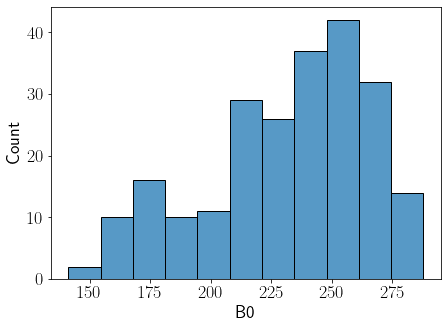

In [41]:
sns.histplot(BS['B0'])

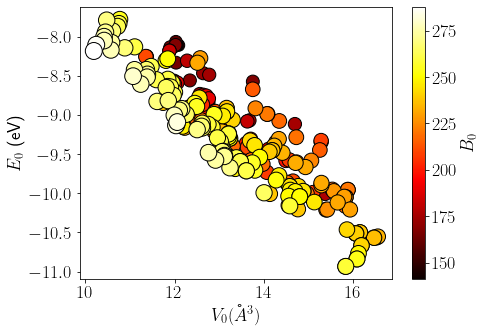

In [42]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.E0, c=BS.B0, marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(r'$E_0$ (eV)')
plt.xlabel(r'$V_0 (\AA^3)$')
cbar.set_label(r'$B_0$')
#outlier_left =BS[(BS['E0']<-10) & (BS['V0']<11)].index
#plt.annotate(outlier_left[0],*BS.loc[outlier_left][['V0', 'E0']].values, fontsize=16 )

In [43]:
volumes = Atoms_Objects['atoms'].map(lambda a: a.get_volume())/BS['num_atoms']

# Atomic volumes vs dft

In [44]:
BS.query('num_atoms == 1').groupby('E0').min('E0')#['V0']#reset_index()

,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
E0,,,,,,,,,,,
-10.932821,1,258.072533,15.828552,1,0,1,0.0,1.0,0.000000,0.000000,0.000000
-10.932755,1,251.877901,15.825081,1,0,1,0.0,1.0,0.000000,0.000000,0.000000
-10.511038,1,239.434813,16.058793,1,0,1,0.0,1.0,0.421787,0.421787,0.421787
-8.255228,1,210.632901,11.356868,1,0,1,1.0,0.0,0.000825,0.000825,0.000825
-8.107128,1,167.384487,12.021393,1,0,1,1.0,0.0,0.342800,0.342800,0.342800
-7.790659,1,269.455898,10.481600,1,0,1,1.0,0.0,0.464170,0.393396,0.314326


In [45]:
Fe_unary = BS.query('num_atoms == 1 and Fe_pv == 1')

In [46]:
V_GS_Fe = Fe_unary[Fe_unary.E0 == Fe_unary.E0.min()].V0

In [47]:
V_GS_Fe

Fe_pv1.bcc.FM    11.356868
Name: V0, dtype: float64

In [48]:
Mo_unary = BS.query('num_atoms == 1 and Mo_sv == 1')

In [49]:
V_GS_Mo = Mo_unary[Mo_unary.E0 == Mo_unary.E0.min()].V0

In [50]:
V_GS_Mo

Mo_sv1.bcc.NM    15.828552
Name: V0, dtype: float64

In [51]:
import mendeleev

In [52]:
Mo = mendeleev.element('Mo')#.metallic_radius

In [53]:
Mo.atomic_volume

9.4

In [54]:
norm = plt.Normalize(BS['Fe_pv'].min(), BS['Fe_pv'].max())

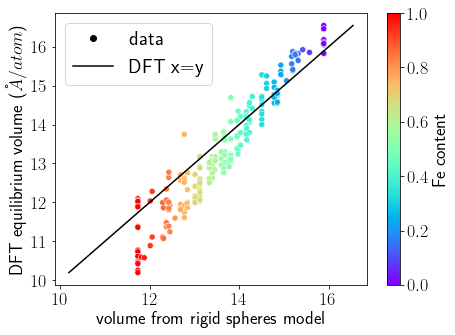

In [55]:
ax  = sns.scatterplot(volumes, BS['V0'], hue=BS['Fe_pv'], palette = 'rainbow', label='data', legend='brief', markers=BS.Phase)
ax = sns.lineplot(BS['V0'], BS['V0'],ax = ax, color='k', label='x=y', legend='brief')#, hue=BS['Fe_pv'], palette='rainbow')
sm = plt.cm.ScalarMappable(norm=norm, cmap='rainbow')
sm.set_array([])
ax.set_ylabel(r'DFT equilibrium volume ($ \AA /atom $)')
ax.set_xlabel('volume from rigid spheres model')
#ax.legend(['data', 'x=y'])
handles = [
    plt.Line2D([0],[0], marker='o', linestyle='', c='k'),
    plt.Line2D([0],[0],linestyle='-', c='k')
]
labels=[
    'data',
    'DFT x=y'
]
ax.legend(handles, labels)
cbar = ax.figure.colorbar(sm)
cbar.set_label('Fe content')
plt.savefig(f'{dataset}/graphs/{dataset}-dftV_vs_gressV.pdf')

In [56]:
BS['V0'].max()

16.546261881028403

In [57]:
volumes[volumes > volumes.max() - 0.1]

Mo_sv2.hcp.FM                     15.891628
Mo_sv24.C36.FM                    15.891628
Mo_sv12.C14.FM                    15.891628
Mo_sv6.C15.NM                     15.891628
Mo_sv6.C15.FM                     15.891628
Mo_sv2.hcp.NM                     15.891628
Mo_sv4.fcc-cubic.FM               15.891628
Mo_sv1.fcc.NM                     15.891628
Mo_sv4.fcc-cubic.NM               15.891628
Mo_sv29.chi.FM                    15.891628
Mo_sv29.chi.NM                    15.891628
Mo_sv30.sigma.FM                  15.891628
Mo_sv1.bcc.FM                     15.891628
Mo_sv8.A15.FM                     15.891628
Mo_sv8.A15.NM                     15.891628
Mo_sv1.bcc.NM                     15.891628
Mo_sv12.C14.NM                    15.891628
Mo_sv24.C36.NM                    15.891628
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM    15.813184
Mo_sv13.mu.FM                     15.891628
Mo_sv13.mu.NM                     15.891628
Mo_sv53.R.NM                      15.891628
Mo_sv53.R-Mo.FM                 

In [58]:
volumes[volumes < volumes.min() + 0.1]

Fe_pv29.chi.FM                    11.734084
Fe_pv6.C15.FM                     11.734084
Fe_pv24.C36.FM                    11.734084
Fe_pv2.hcp.FM                     11.734084
Fe_pv4.fcc-cubic.FM               11.734084
Fe_pv13.mu.FM                     11.734084
Fe_pv1.fcc.FM                     11.734084
Fe_pv30.sigma.FM                  11.734084
Fe_pv30.sigma_Fe_pv.FM            11.734084
Fe_pv2.bcc-cubic.FM               11.734084
Fe_pv1.bcc.FM                     11.734084
Fe_pv6.C15.NM                     11.734084
Fe_pv24.C36.NM                    11.734084
Fe_pv12.C14.NM                    11.734084
Fe_pv13.mu.NM                     11.734084
Fe_pv1.bcc.NM                     11.734084
Fe_pv8.A15.NM                     11.734084
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM    11.812528
Fe_pv30.sigma.NM                  11.734084
Fe_pv29.chi.NM                    11.734084
Fe_pv4.fcc-cubic.NM               11.734084
Fe_pv2.hcp.NM                     11.734084
Fe_pv53.R.NM                    

In [59]:
BS.index.str.contains('FM').sum()

118

In [60]:
BS.index.str.contains('NM').sum()

174

In [61]:
febcc = Atoms_Objects.atoms[Atoms_Objects.index.str.contains(r'Fe.*bcc.*FM', regex=True)]

In [62]:
len(febcc[0])

2

In [63]:
BS.loc[febcc.index].num_atom_A

Fe_pv2.bcc-cubic.FM    2
Fe_pv1.bcc.FM          1
Name: num_atom_A, dtype: int64

In [64]:
BS.columns

Index(['', 'V', 'E0', 'B', 'fit', 'xc', 'encut', 'deltak', 'ncrash', 'nelem',
       'B0', 'V0', 'atom_A', 'atom_B', 'num_atom_A', 'num_atom_B', 'num_atoms',
       'Fe_pv', 'Mo_sv', 'EF_fmbcc', 'EF_nmhcp', 'EF_nmfcc', 'Phase'],
      dtype='object')

In [65]:
BS.EF_fmbcc

Fe_pv29.chi.FM                  0.117795
Fe_pv6.C15.FM                   0.143766
Fe_pv24.C36.FM                  0.145129
Fe_pv2.hcp.FM                   0.189213
Fe_pv4.fcc-cubic.FM             0.193968
                                  ...   
Fe_pv2Mo_sv11.mu-BBBBA.FM       0.374468
Fe_pv6Mo_sv24.sigma-AABBB.FM    0.235002
Fe_pv4Mo_sv26.sigma-BABBB.FM    0.312380
Fe_pv16Mo_sv8.C36-ABBAA.NM      0.232895
Fe_pv4Mo_sv9.mu-BBBAA.FM        0.496180
Name: EF_fmbcc, Length: 292, dtype: float64